In [11]:
import os
# --- 0. FIX for OpenMP Error ---
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import glob
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # For 3D plotting
import time

print(f"PyTorch Version: {torch.__version__}")

# --- 1. Parameters ---
NUM_POINTS = 1024
NUM_CLASSES = 16   # ShapeNetPart has 16 categories
BATCH_SIZE = 8     # SAFETY EDIT: Small batch size
EPOCHS = 1         # SAFETY EDIT: Few epochs

# --- !! IMPORTANT: VERIFY THIS PATH !! ---
# Should point to the folder containing train*.h5, test*.h5 etc.
DATA_DIR = r"C:\Users\phane\OneDrive\Documents\Collge Internship Work (NITPY)\shapenetpart_hdf5_2048_3D_Project\shapenetpart_hdf5_2048"
MODEL_SAVE_PATH = "shapenet_classifier_pytorch.pth"

# --- Category Names Mapping ---
category_names = [
    "Airplane",    # 0 "Bag",         # 1 "Cap",         # 2
    "Car",         # 3 "Chair",       # 4 "Earphone",    # 5
    "Guitar",      # 6 "Knife",       # 7 "Lamp",        # 8
    "Laptop",      # 9 "Motorbike",   # 10 "Mug",         # 11
    "Pistol",      # 12 "Rocket",      # 13 "Skateboard",  # 14
    "Table"        # 15
]

# --- GPU Check ---
print("\n--- GPU/CUDA Check ---")
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ CUDA GPU found and available!")
    print(f"   Device Name: {torch.cuda.get_device_name(0)}")
    print(f"   Number of GPUs: {torch.cuda.device_count()}")
else:
    device = torch.device("cpu")
    print("❌ No CUDA GPU found. PyTorch will use the CPU.")
print(f"   Using device: {device}")
print("--------------------\n")

# --- Function to load data (run once) ---
# Global variables to store loaded data
train_points, train_labels, test_points, test_labels = None, None, None, None

def load_shapenet_data_global(data_dir):
    """Loads ShapeNetPart h5 files into global variables."""
    global train_points, train_labels, test_points, test_labels
    start_time = time.time()
    if not os.path.isdir(data_dir):
         print(f"❌ ERROR: DATA_DIR does not exist: {data_dir}")
         return False

    train_files = glob.glob(os.path.join(data_dir, "train*.h5"))
    test_files = glob.glob(os.path.join(data_dir, "test*.h5"))

    if not train_files or not test_files:
        print(f"❌ ERROR: No 'train*.h5' or 'test*.h5' files found directly inside '{data_dir}'")
        return False

    print(f"Found {len(train_files)} training H5 file parts.")
    print(f"Found {len(test_files)} test H5 file parts.")

    try:
        train_data_list = []
        train_labels_list = []
        print("Loading training files...")
        for h5_file in train_files:
            with h5py.File(h5_file, 'r') as f:
                train_data_list.append(f['data'][:])
                train_labels_list.append(f['label'][:])

        test_data_list = []
        test_labels_list = []
        print("Loading test files...")
        for h5_file in test_files:
             with h5py.File(h5_file, 'r') as f:
                test_data_list.append(f['data'][:])
                test_labels_list.append(f['label'][:])

        print("Concatenating data...")
        # Store as NumPy arrays initially
        train_points = np.concatenate(train_data_list, axis=0)
        train_labels = np.concatenate(train_labels_list, axis=0).squeeze().astype(np.int64) # Labels for CrossEntropyLoss
        test_points = np.concatenate(test_data_list, axis=0)
        test_labels = np.concatenate(test_labels_list, axis=0).squeeze().astype(np.int64)

        end_time = time.time()
        print(f"Data loaded successfully in {end_time - start_time:.2f} seconds.")
        print(f"Train points shape: {train_points.shape}, Train labels shape: {train_labels.shape}")
        print(f"Test points shape: {test_points.shape}, Test labels shape: {test_labels.shape}")
        print(f"Unique train labels: {np.unique(train_labels)}")
        print(f"Unique test labels: {np.unique(test_labels)}")
        return True

    except Exception as e:
        print(f"❌ ERROR loading H5 files: {e}")
        return False

# --- Load the data ---
print(f"Looking for data in: {os.path.abspath(DATA_DIR)}")
data_loaded = load_shapenet_data_global(DATA_DIR)

PyTorch Version: 2.5.1

--- GPU/CUDA Check ---
✅ CUDA GPU found and available!
   Device Name: NVIDIA GeForce RTX 4050 Laptop GPU
   Number of GPUs: 1
   Using device: cuda
--------------------

Looking for data in: C:\Users\phane\OneDrive\Documents\Collge Internship Work (NITPY)\shapenetpart_hdf5_2048_3D_Project\shapenetpart_hdf5_2048
Found 6 training H5 file parts.
Found 2 test H5 file parts.
Loading training files...
Loading test files...
Concatenating data...
Data loaded successfully in 0.35 seconds.
Train points shape: (12137, 2048, 3), Train labels shape: (12137,)
Test points shape: (2874, 2048, 3), Test labels shape: (2874,)
Unique train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
Unique test labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]



Creating PyTorch Datasets and DataLoaders...
DataLoaders created successfully.

Displaying one sample point cloud from DataLoader...


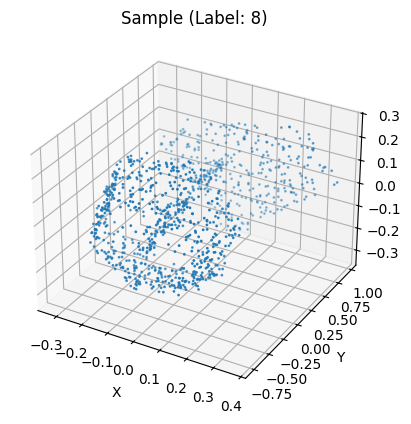

In [2]:
# --- 3. PyTorch Dataset Class ---
class ShapeNetPartClassificationDataset(Dataset):
    def __init__(self, points_np, labels_np, num_points=NUM_POINTS, is_training=True):
        self.points = points_np
        self.labels = labels_np
        self.num_points = num_points
        self.is_training = is_training

    def __len__(self):
        return len(self.points)

    def __getitem__(self, idx):
        raw_points = self.points[idx] # Shape (2048, 3)
        label = self.labels[idx]      # Shape () scalar

        # --- Preprocessing (Sampling, Normalizing, Augmenting) ---
        # 1. Sample points
        if raw_points.shape[0] > self.num_points:
            choice = np.random.choice(raw_points.shape[0], self.num_points, replace=False)
        else: # Should not happen with this dataset, but safe fallback
            choice = np.random.choice(raw_points.shape[0], self.num_points, replace=True)
        sampled_points = raw_points[choice, :]

        # 2. Normalize
        centroid = np.mean(sampled_points, axis=0)
        normalized_points = sampled_points - centroid
        dist = np.max(np.sqrt(np.sum(normalized_points ** 2, axis=1))) + 1e-8
        normalized_points = normalized_points / dist

        # 3. Augment if training
        if self.is_training:
            # Jitter
            jitter = np.clip(0.01 * np.random.randn(*normalized_points.shape), -0.05, 0.05)
            normalized_points += jitter
            # Rotate
            angle = np.random.uniform() * 2 * np.pi
            cosval = np.cos(angle)
            sinval = np.sin(angle)
            rotation_matrix = np.array([[cosval, -sinval, 0],
                                        [sinval, cosval, 0],
                                        [0, 0, 1]], dtype=np.float32)
            normalized_points = np.dot(normalized_points, rotation_matrix)

        # Convert to PyTorch tensors
        # PointNet expects (Batch, Features, Num_Points) -> Transpose!
        points_tensor = torch.from_numpy(normalized_points).float().transpose(0, 1) # Shape (3, num_points)
        label_tensor = torch.tensor(label, dtype=torch.long) # Use torch.long for CrossEntropyLoss

        return points_tensor, label_tensor

# --- 4. Visualization Function ---
def display_point_cloud_np(points_np, title="Point Cloud"):
    """Takes NumPy array (N, 3)"""
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2], s=1)
    ax.set_title(title)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    # plt.show() # Often shows automatically in notebooks

# --- Create Datasets and DataLoaders ---
if data_loaded: # Only if data was loaded successfully
    print("\nCreating PyTorch Datasets and DataLoaders...")
    try:
        train_dset = ShapeNetPartClassificationDataset(train_points, train_labels, is_training=True)
        test_dset = ShapeNetPartClassificationDataset(test_points, test_labels, is_training=False)

        train_loader = DataLoader(train_dset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0) # num_workers=0 for Windows usually safer
        test_loader = DataLoader(test_dset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
        print("DataLoaders created successfully.")

        # --- Display a sample from DataLoader ---
        print("\nDisplaying one sample point cloud from DataLoader...")
        sample_points_tensor, sample_label_tensor = next(iter(train_loader))
        # Transpose back to (N, 3) and convert to numpy for display
        sample_points_np = sample_points_tensor[0].transpose(0, 1).numpy()
        display_point_cloud_np(sample_points_np, title=f"Sample (Label: {sample_label_tensor[0].item()})")
        plt.show()

    except Exception as e:
        print(f"❌ ERROR creating Datasets/DataLoaders or displaying sample: {e}")
        train_loader = None
        test_loader = None
else:
    print("\nSkipping Dataset creation.")
    train_loader = None
    test_loader = None

In [12]:
import torch.nn.functional as F # Need F for activation functions

# --- 5. PointNet++ Model Architecture (PyTorch) ---

# Farthest Point Sampling (Adapted for PyTorch)
# Note: For optimal performance on large datasets, a CUDA implementation is preferred.
def farthest_point_sample_pytorch(xyz, npoint):
    """
    Input: xyz: pointcloud data, [B, N, 3] ; npoint: number of samples
    Return: centroids_idx: sampled pointcloud index, [B, npoint]
    """
    device = xyz.device
    B, N, C = xyz.shape
    centroids_idx = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    # Randomly select the first point index for each batch element
    farthest_idx = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)

    for i in range(npoint):
        centroids_idx[:, i] = farthest_idx
        # Get the coordinates of the chosen centroids
        centroid = xyz[batch_indices, farthest_idx, :].view(B, 1, 3)
        # Calculate squared distances from all points to the chosen centroid
        dist = torch.sum((xyz - centroid) ** 2, -1)
        # Create a mask where the new distance is smaller than the current minimum distance
        mask = dist < distance
        # Update the minimum distance for points closer to the new centroid
        distance[mask] = dist[mask]
        # Find the index of the point with the maximum minimum distance (farthest point)
        farthest_idx = torch.max(distance, -1)[1]
    return centroids_idx


# PointNet Set Abstraction Layer (Corrected Initialization)
class PointNetSetAbstraction(nn.Module):
    # <<< FIX: Added 'in_channel' argument >>>
    def __init__(self, npoint, mlp, in_channel=3):
        super(PointNetSetAbstraction, self).__init__()
        self.npoint = npoint
        self.mlp_convs = nn.ModuleList()
        self.mlp_bns = nn.ModuleList()

        # <<< FIX: Use the 'in_channel' argument for the first layer's input size >>>
        last_channel = in_channel
        for out_channel in mlp:
            self.mlp_convs.append(nn.Conv1d(last_channel, out_channel, 1))
            self.mlp_bns.append(nn.BatchNorm1d(out_channel))
            last_channel = out_channel
        self.last_channel_out = last_channel

    def forward(self, xyz, features):
        """
        Input:
            xyz: input points position data, [B, N, 3]
            features: input points feature data, [B, C_in, N] or None
        Return:
            new_xyz: sampled points position data, [B, npoint, 3] or None
            new_features: sample points feature data, [B, C_out, npoint] or [B, C_out, 1]
        """
        B, N, _ = xyz.shape
        device = xyz.device

        # Sample points' indices using FPS
        if self.npoint is not None:
            if N < self.npoint:
                 fps_indices = torch.arange(N, dtype=torch.long).unsqueeze(0).expand(B,-1).to(device)
                 current_npoint = N
                 print(f"Warning: N({N}) < npoint({self.npoint}), using N points in SA layer.")
            else:
                 fps_indices = farthest_point_sample_pytorch(xyz, self.npoint) # [B, npoint]
                 current_npoint = self.npoint
            # Gather the coordinates of the sampled points
            new_xyz = xyz[torch.arange(B).unsqueeze(1), fps_indices] # [B, npoint, 3]
        else: # Global abstraction
            new_xyz = None
            fps_indices = None
            current_npoint = 1 # Global feature is like 1 point

        # Determine input features for MLPs
        if features is None:
             # Use XYZ coordinates as input features if none provided
             x = xyz.transpose(1, 2).contiguous() # [B, 3, N]
             input_feature_dim = 3
             # <<< FIX: Check if first layer matches expected input_dim (3) >>>
             if self.mlp_convs[0].in_channels != 3:
                 # This should ideally not happen if constructed correctly, but handles edge case
                 print(f"Warning: First MLP layer expected {self.mlp_convs[0].in_channels} but got 3. Rebuilding layer.")
                 self.mlp_convs[0] = nn.Conv1d(3, self.mlp_convs[0].out_channels, 1).to(device)
        else:
             x = features # Already [B, C_in, N]
             input_feature_dim = x.shape[1]
             # <<< FIX: Check if first layer matches actual feature input_dim >>>
             if self.mlp_convs[0].in_channels != input_feature_dim:
                 # This *will* happen for layers after the first if not initialized correctly
                 # print(f"Adjusting first MLP layer in_channels from {self.mlp_convs[0].in_channels} to {input_feature_dim}")
                 self.mlp_convs[0] = nn.Conv1d(input_feature_dim, self.mlp_convs[0].out_channels, 1).to(device)


        # Apply MLPs
        for i, conv in enumerate(self.mlp_convs):
            bn = self.mlp_bns[i]
            x = F.relu(bn(conv(x))) # [B, mlp[i], N]

        # Gather/Pool features
        if fps_indices is not None:
            # Gather features corresponding to sampled points
            indices_expanded = fps_indices.unsqueeze(1).expand(-1, x.size(1), -1) # [B, C_out, npoint]
            new_features = torch.gather(x, 2, indices_expanded) # [B, C_out, npoint]
        else: # Global abstraction (Max Pooling)
            new_features = torch.max(x, 2)[0].unsqueeze(-1) # [B, C_out, 1]

        return new_xyz, new_features


# The full PointNet++ Classification Model (Corrected Initialization)
class PointNetPlusPlusCls(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(PointNetPlusPlusCls, self).__init__()
        # <<< FIX: Pass correct 'in_channel' arguments >>>
        self.sa1 = PointNetSetAbstraction(npoint=512, mlp=[64, 64, 128], in_channel=3)
        # Output of sa1 is 128 channels
        self.sa2 = PointNetSetAbstraction(npoint=128, mlp=[128, 128, 256], in_channel=128)
        # Output of sa2 is 256 channels
        self.sa3 = PointNetSetAbstraction(npoint=None, mlp=[256, 512, 1024], in_channel=256)

        # Classification Head remains the same
        self.fc1 = nn.Linear(1024, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.drop1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.drop2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(256, num_classes)

    def forward(self, xyz):
        """
        Input:
             xyz: Input points (batch_size, 3, num_points) <- NOTE: Transposed input
        """
        B, C, N = xyz.shape
        if C != 3:
            # Maybe handle cases with extra features later, but for now expect 3
            raise ValueError(f"Input tensor must have 3 channels (XYZ), got {C}")

        # Transpose input xyz to (B, N, 3) for FPS sampling and coordinate usage in SA layers
        xyz_transposed = xyz.transpose(1, 2).contiguous()

        # Encoder
        # sa1 input features are None (it uses xyz_transposed internally)
        l1_xyz, l1_points = self.sa1(xyz_transposed, None) # Features start as None -> output [B, 128, 512]
        # sa2 input features are l1_points
        l2_xyz, l2_points = self.sa2(l1_xyz, l1_points) # Output [B, 256, 128]
        # sa3 input features are l2_points
        l3_xyz, l3_points = self.sa3(l2_xyz, l2_points) # Output [B, 1024, 1]

        # Global feature vector
        x = l3_points.view(B, 1024) # Flatten to [B, 1024]

        # Classification Head
        x = self.drop1(F.relu(self.bn1(self.fc1(x))))
        x = self.drop2(F.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)

        # Output raw scores (logits)
        return x

# --- Build the model ---
# (This ensures the corrected model is built and ready for Cell 4)
if 'data_loaded' in locals() and data_loaded:
    print("\nBuilding PyTorch model with corrected layers...")
    try:
        model = PointNetPlusPlusCls(num_classes=NUM_CLASSES).to(device)
        print(f"Model built successfully and moved to {device}.")
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total Parameters: {total_params:,}")
        print(f"Trainable Parameters: {trainable_params:,}")
    except Exception as e:
        print(f"❌ ERROR building model: {e}")
        model = None
else:
    print("\nSkipping model building.")
    model = None


Building PyTorch model with corrected layers...
Model built successfully and moved to cuda.
Total Parameters: 1,468,368
Trainable Parameters: 1,468,368


In [4]:
# --- Training Loop & Save Model ---
if 'model' in locals() and model is not None and train_loader is not None:
    print("\nStarting training...")
    start_train_time = time.time()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001) # You can add weight_decay=1e-4 here if desired

    # Training for EPOCHS
    for epoch in range(EPOCHS):
        epoch_start_time = time.time()
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        skipped_batches = 0 # <<< ADDED: Counter for skipped batches >>>
        print(f"--- Epoch {epoch+1}/{EPOCHS} ---")

        for batch_idx, (points, labels) in enumerate(train_loader):
            points, labels = points.to(device), labels.to(device) # Move data to device

            # <<< ADDED BLOCK: Check batch size >>>
            current_batch_size = points.size(0)
            if current_batch_size < 2:
                # print(f"  Skipping batch {batch_idx+1} because batch size ({current_batch_size}) is less than 2.") # Optional: Print skip message
                skipped_batches += 1
                continue # Skip this batch
            # <<< END ADDED BLOCK >>>

            optimizer.zero_grad()
            outputs = model(points) # Forward pass, input shape (B, 3, N)
            loss = criterion(outputs, labels) # Calculate loss
            loss.backward() # Backward pass
            optimizer.step() # Update weights

            # Statistics
            running_loss += loss.item() * points.size(0) # Use current_batch_size
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0) # Use current_batch_size
            correct_predictions += (predicted == labels).sum().item()

            if (batch_idx + 1) % 100 == 0: # Print progress every 100 batches
                 # Calculate current average loss/accuracy for printing (based on processed samples)
                 processed_samples = total_samples if total_samples > 0 else 1 # Avoid division by zero
                 current_loss = running_loss / processed_samples
                 current_acc = correct_predictions / processed_samples * 100
                 print(f'  Batch {batch_idx+1}/{len(train_loader)}, Processed Samples: {total_samples}, Current Avg Loss: {current_loss:.4f}, Current Avg Acc: {current_acc:.2f}%')

        # Calculate epoch loss and accuracy based on total processed samples
        epoch_loss = running_loss / total_samples if total_samples > 0 else 0
        epoch_acc = correct_predictions / total_samples * 100 if total_samples > 0 else 0
        epoch_end_time = time.time()

        print(f"Epoch {epoch+1} finished in {epoch_end_time - epoch_start_time:.2f}s")
        if skipped_batches > 0:
            print(f"  (Skipped {skipped_batches} batches with size < 2)") # <<< ADDED: Report skipped batches >>>
        if total_samples > 0:
             print(f"  Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}% ({correct_predictions}/{total_samples})")
        else:
             print("  No batches processed in this epoch.")


    end_train_time = time.time()
    print(f"\nTraining finished in {end_train_time - start_train_time:.2f} seconds.")

    # --- Save the Trained Model State Dictionary ---
    print("\nSaving the trained model state dictionary...")
    try:
        # Save only the model's learned parameters (recommended)
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Model state saved successfully to {MODEL_SAVE_PATH}")
    except Exception as e:
        print(f"❌ ERROR saving model state: {e}")

else:
    print("\nSkipping training because model or data loader is not available.")


Starting training...
--- Epoch 1/1 ---
  Batch 100/1518, Processed Samples: 800, Current Avg Loss: 1.5882, Current Avg Acc: 53.37%
  Batch 200/1518, Processed Samples: 1600, Current Avg Loss: 1.4655, Current Avg Acc: 55.94%
  Batch 300/1518, Processed Samples: 2400, Current Avg Loss: 1.3903, Current Avg Acc: 57.12%
  Batch 400/1518, Processed Samples: 3200, Current Avg Loss: 1.3210, Current Avg Acc: 59.34%
  Batch 500/1518, Processed Samples: 4000, Current Avg Loss: 1.2759, Current Avg Acc: 60.45%
  Batch 600/1518, Processed Samples: 4800, Current Avg Loss: 1.2379, Current Avg Acc: 61.40%
  Batch 700/1518, Processed Samples: 5600, Current Avg Loss: 1.2138, Current Avg Acc: 61.93%
  Batch 800/1518, Processed Samples: 6400, Current Avg Loss: 1.1900, Current Avg Acc: 62.44%
  Batch 900/1518, Processed Samples: 7200, Current Avg Loss: 1.1677, Current Avg Acc: 62.78%
  Batch 1000/1518, Processed Samples: 8000, Current Avg Loss: 1.1380, Current Avg Acc: 63.82%
  Batch 1100/1518, Processed S

In [5]:
# --- Evaluate Model ---
if 'model' in locals() and model is not None and test_loader is not None:
    print("\nEvaluating model on test set...")
    start_eval_time = time.time()
    model.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss() # Need criterion for loss calculation

    with torch.no_grad(): # Disable gradient calculations for evaluation
        for points, labels in test_loader:
            points, labels = points.to(device), labels.to(device)
            outputs = model(points)
            loss = criterion(outputs, labels)
            test_loss += loss.item() * points.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / total
    test_accuracy = 100 * correct / total
    end_eval_time = time.time()
    print(f"Evaluation finished in {end_eval_time - start_eval_time:.2f} seconds.")
    print(f"\nTest Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")

else:
    print("\nSkipping evaluation.")


Evaluating model on test set...
Evaluation finished in 74.75 seconds.

Test Loss: 0.7018
Test Accuracy: 77.87%


--- Running Simplified Cell 6 ---
DEBUG Cell 6: Redefined local_category_names with length: 16

Loading model state from shapenet_classifier_pytorch.pth...
Model state loaded successfully.

--- Classifying a single object ---
Selected random object index: 1494
DEBUG: Checking true label 15 against len(local_category_names)=16
Loading object index 1494 (True Label: 15 - Table)...
Input shape for prediction: torch.Size([1, 3, 1024])
Running prediction...
DEBUG: Checking predicted index 15 against len(local_category_names)=16

Model Prediction:
  - Predicted Class: 15 (Table)
  - Confidence: 89.97%
  - True Class:      15 (Table)

Displaying the object...

--- Simplified Cell 6 Finished ---


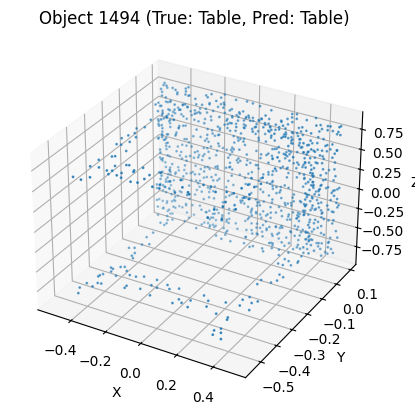

In [15]:
# --- Load Saved Model State and Classify Single Object ---

import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Ensure Axes3D is imported if needed by display func
print("--- Running Simplified Cell 6 ---") # Add clear marker

# --- Define function to load model state ---
# (Keep the load_model_state function definition from the previous version)
def load_model_state(model_instance, path, device):
    """Loads a PyTorch model state dictionary from a file."""
    print(f"\nLoading model state from {path}...")
    if os.path.exists(path):
        try:
            state_dict = torch.load(path, map_location=device, weights_only=True)
            model_instance.load_state_dict(state_dict)
            model_instance.to(device)
            model_instance.eval()
            print("Model state loaded successfully.")
            return model_instance
        except Exception as e:
            print(f"❌ ERROR loading model state: {e}")
            return None
    else:
        print(f"Model state file '{path}' not found. Train and save the model first.")
        return None

# --- Re-define crucial parameters and names LOCALLY ---
# This ensures they are correct within this cell's scope
LOCAL_NUM_CLASSES = 16
LOCAL_NUM_POINTS = 1024 # Should match NUM_POINTS used in training/preprocessing
local_category_names = [
    "Airplane", "Bag", "Cap", "Car", "Chair", "Earphone", "Guitar", "Knife",
    "Lamp", "Laptop", "Motorbike", "Mug", "Pistol", "Rocket", "Skateboard", "Table"
]
print(f"DEBUG Cell 6: Redefined local_category_names with length: {len(local_category_names)}")


# --- Ensure display function is available ---
if 'display_point_cloud_np' not in globals():
    # Define it here if it might be missing (copy from Cell 2 if needed)
    print("WARNING: display_point_cloud_np function not found, defining basic one.")
    def display_point_cloud_np(points_np, title="Point Cloud"):
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        if points_np.shape[0] > 0:
            ax.scatter(points_np[:, 0], points_np[:, 1], points_np[:, 2], s=2)
        ax.set_title(title)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.view_init(elev=20, azim=45)
        plt.show()

# --- Load the model ---
# Ensure PointNetPlusPlusCls class is defined (run Cell 3 first)
loaded_model = None
if 'PointNetPlusPlusCls' in globals():
    # Use LOCAL_NUM_CLASSES when creating instance
    temp_model = PointNetPlusPlusCls(num_classes=LOCAL_NUM_CLASSES)
    # Ensure device is defined (should be from Cell 1)
    current_device = device if 'device' in locals() else torch.device("cpu")
    loaded_model = load_model_state(temp_model, MODEL_SAVE_PATH, current_device)
else:
    print("❌ ERROR: PointNetPlusPlusCls class definition not found. Run Cell 3.")

# --- Classify if model and data are ready ---
if loaded_model is not None and 'test_points' in locals() and test_points is not None and 'test_labels' in locals() and test_labels is not None:
    print("\n--- Classifying a single object ---")
    try:
        object_index = random.randint(0, len(test_points) - 1)
        print(f"Selected random object index: {object_index}")

        single_object_raw = test_points[object_index]
        true_label_index = test_labels[object_index]

        # Check true label index against the LOCAL list
        print(f"DEBUG: Checking true label {true_label_index} against len(local_category_names)={len(local_category_names)}")
        if 0 <= true_label_index < len(local_category_names):
            true_name = local_category_names[true_label_index]
            print(f"Loading object index {object_index} (True Label: {true_label_index} - {true_name})...")
        else:
            true_name = f"INVALID_LABEL({true_label_index})"
            print(f"❌ ERROR: True Label index {true_label_index} out of bounds for local_category_names (len={len(local_category_names)}).")

        # --- Preprocess ---
        if single_object_raw.shape[0] > LOCAL_NUM_POINTS:
             choice = np.random.choice(single_object_raw.shape[0], LOCAL_NUM_POINTS, replace=False)
        else:
             choice = np.random.choice(single_object_raw.shape[0], LOCAL_NUM_POINTS, replace=True)
        sampled_points = single_object_raw[choice, :]
        centroid = np.mean(sampled_points, axis=0)
        normalized_points_np = sampled_points - centroid
        dist = np.max(np.sqrt(np.sum(normalized_points_np ** 2, axis=1))) + 1e-8
        normalized_points_np = normalized_points_np / dist

        # Convert to Tensor
        single_object_tensor = torch.from_numpy(normalized_points_np).float().transpose(0, 1).unsqueeze(0).to(current_device) # Use current_device
        print(f"Input shape for prediction: {single_object_tensor.shape}")

        print("Running prediction...")
        with torch.no_grad():
            predictions = loaded_model(single_object_tensor)

        probabilities = torch.softmax(predictions, dim=1)[0]
        confidence, predicted_class_index_tensor = torch.max(probabilities, 0)
        predicted_class_index = predicted_class_index_tensor.cpu().item()
        confidence = confidence.cpu().item()

        # Check predicted index against the LOCAL list
        print(f"DEBUG: Checking predicted index {predicted_class_index} against len(local_category_names)={len(local_category_names)}")
        if 0 <= predicted_class_index < len(local_category_names):
             predicted_name = local_category_names[predicted_class_index]
        else:
             predicted_name = f"INVALID_PREDICTION({predicted_class_index})"
             print(f"❌ ERROR: Predicted index {predicted_class_index} out of bounds for local_category_names (len={len(local_category_names)}).")

        print(f"\nModel Prediction:")
        print(f"  - Predicted Class: {predicted_class_index} ({predicted_name})")
        print(f"  - Confidence: {confidence*100:.2f}%")
        print(f"  - True Class:      {true_label_index} ({true_name})")

        print("\nDisplaying the object...")
        display_point_cloud_np(
            normalized_points_np,
            title=f"Object {object_index} (True: {true_name}, Pred: {predicted_name})"
        )

    except Exception as e:
        print(f"❌ ERROR during single object classification: {e}")
else:
    print("\nSkipping single object classification as loaded model or test data is not available.")

print("\n--- Simplified Cell 6 Finished ---") # Add finish marker